## Name: Saddam Hussain
## Batch: PGD DS-AI Batch-10

# Question: 04

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
df = pd.read_csv('data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

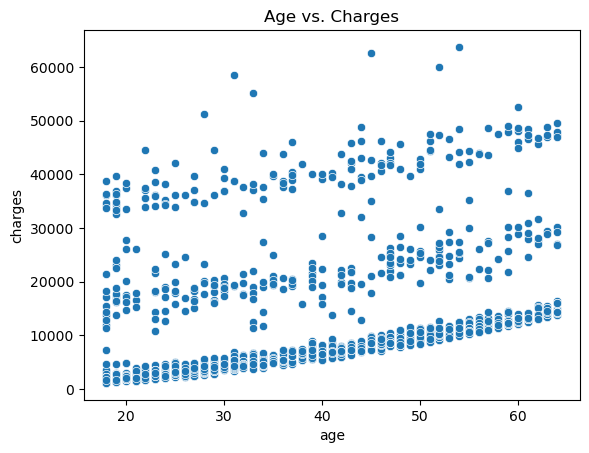

In [6]:
# Age vs. Charges
plt.figure()
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs. Charges')
plt.show()

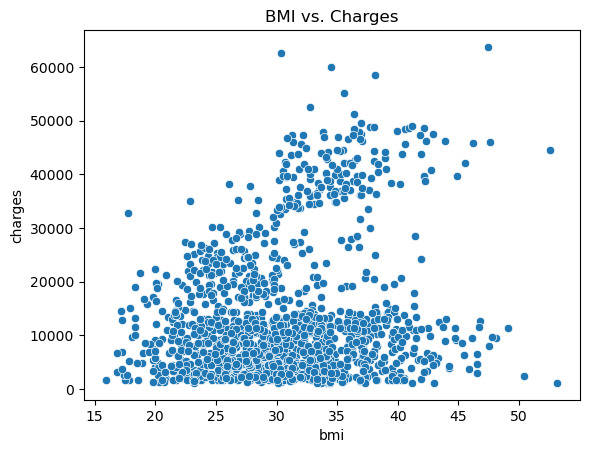

In [7]:
# BMI vs. Charges
plt.figure()
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs. Charges')
plt.show()

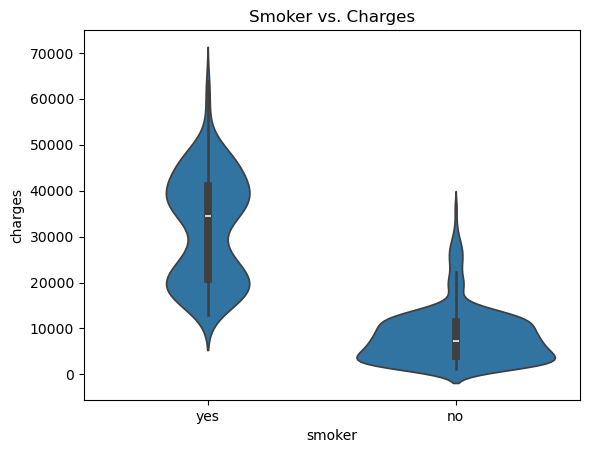

In [8]:
# Smoker vs. Charges
plt.figure()
sns.violinplot(x='smoker', y='charges', data=df)
plt.title('Smoker vs. Charges')
plt.show()

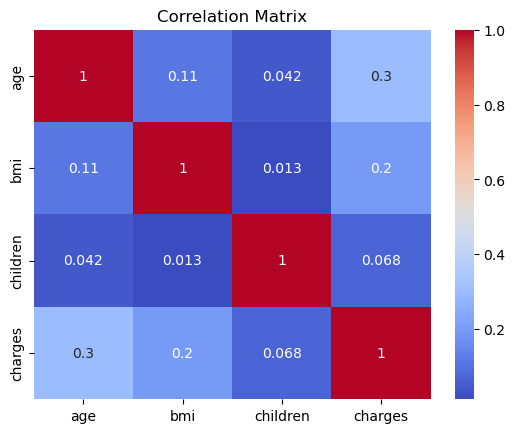

In [9]:
# Correlation Matrix
plt.figure()
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

In [11]:
# Label encode the 'smoker' column
le = LabelEncoder()
X['smoker'] = le.fit_transform(X['smoker'])

In [12]:
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'region']

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
regressors = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

In [16]:
# Creating pipelines for each model
pipelines = {}
pipelines['Linear Regression'] = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', regressors['Linear Regression'])])
pipelines['Random Forest'] = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', regressors['Random Forest'])])

In [17]:
results = {}

# Training Linear Regression

linear_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
linear_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'region'])])),
                ('regressor', LinearRegression())])

In [18]:
y_pred_lr = linear_reg_pipeline.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)


rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
results['Linear Regression'] = {'R2': r2_lr, 'RMSE': rmse_lr}


print(f"  R2 Score: {r2_lr:.4f}")
print(f"  RMSE: {rmse_lr:.2f}")


  R2 Score: 0.1618
  RMSE: 11407.57


In [19]:
# Training Random Forest model
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'region'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [20]:
y_pred_rf = random_forest_pipeline.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
results['Random Forest'] = {'R2': r2_rf, 'RMSE': rmse_rf}


print(f"  R2 Score: {r2_rf:.4f}")
print(f"  RMSE: {rmse_rf:.2f}")


  R2 Score: 0.0441
  RMSE: 12181.78


In [21]:
print("Comparison of Models:")
print(f"Linear Regression: R2 = {results['Linear Regression']['R2']:.4f}, RMSE = {results['Linear Regression']['RMSE']:.2f}")
print(f"Random Forest: R2 = {results['Random Forest']['R2']:.4f}, RMSE = {results['Random Forest']['RMSE']:.2f}")

Comparison of Models:
Linear Regression: R2 = 0.1618, RMSE = 11407.57
Random Forest: R2 = 0.0441, RMSE = 12181.78


In [22]:
from sklearn.model_selection import GridSearchCV


best_model = RandomForestRegressor(random_state=42)


pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', best_model)])


param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20]
}


grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='r2')


grid.fit(X_train, y_train)


print("Best Parameters:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Parameters: {'regressor__max_depth': 10, 'regressor__n_estimators': 100}
Best R2 Score: -0.02034345469860861
